In [1]:
import os
os.chdir('/home/smallyan/eval_agent')
print(f"Working directory: {os.getcwd()}")

Working directory: /home/smallyan/eval_agent


# Belief Tracking Replication Study

## Goal
Replicate the belief tracking experiments from "Language Models use Lookbacks to Track Beliefs" (Prakash et al., 2025).

This notebook reimplements the causal intervention analysis to verify:
1. Answer lookback pointer localization (layers 34-52)
2. Answer lookback payload localization (layers 56+)

## Key Concepts
- **Interchange Intervention Accuracy (IIA)**: Measures whether patching activations from counterfactual prompts changes output to target
- **Answer Pointer**: Information encoding which state token to retrieve (encoded at layers 34-52)
- **Answer Payload**: The actual state value to output (encoded after layer 56)

In [2]:
# Setup and imports
import json
import os
import random
from dataclasses import dataclass
from typing import Literal, Optional, List, Dict

import torch
import matplotlib.pyplot as plt

# Check CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda
GPU: NVIDIA A100 80GB PCIe
GPU Memory: 85.09 GB


## Data Generation

Reimplementing the CausalToM dataset generation. The dataset creates stories about characters working in a restaurant, filling containers with drinks. Different templates control visibility of actions between characters.

In [3]:
# Define data paths
DATA_DIR = "/net/scratch2/smallyan/belief_tracking_eval/data"

# Load entity lists
with open(os.path.join(DATA_DIR, "synthetic_entities", "characters.json"), "r") as f:
    ALL_CHARACTERS = json.load(f)
    
with open(os.path.join(DATA_DIR, "synthetic_entities", "bottles.json"), "r") as f:
    ALL_OBJECTS = json.load(f)
    
with open(os.path.join(DATA_DIR, "synthetic_entities", "drinks.json"), "r") as f:
    ALL_STATES = json.load(f)
    
# Load story templates
with open(os.path.join(DATA_DIR, "story_templates.json"), "r") as f:
    STORY_TEMPLATES = json.load(f)

print(f"Loaded {len(ALL_CHARACTERS)} characters")
print(f"Loaded {len(ALL_OBJECTS)} objects (containers)")
print(f"Loaded {len(ALL_STATES)} states (drinks)")
print(f"Loaded {len(STORY_TEMPLATES['templates'])} story templates")

Loaded 103 characters
Loaded 21 objects (containers)
Loaded 23 states (drinks)
Loaded 4 story templates


In [4]:
# Reimplemented Sample class for generating belief tracking stories
@dataclass
class BeliefSample:
    """A sample from the CausalToM dataset representing a belief tracking scenario."""
    template_idx: int
    characters: List[str]
    objects: List[str]  
    states: List[str]
    story: Optional[str] = None
    character_belief: Optional[List[Dict[str, str]]] = None
    
    def __post_init__(self):
        # Ensure we have 2 characters
        if len(self.characters) == 1:
            self.characters.append("<N/A>")
        
        # Validate no duplicates
        assert len(set(self.states)) == len(self.states), "States must be unique"
        assert len(set(self.objects)) == len(self.objects), "Objects must be unique"
        assert len(set(self.characters)) == len(self.characters), "Characters must be unique"
        
        self._generate_story()
    
    def _generate_story(self):
        """Generate the story text and set character beliefs."""
        template = STORY_TEMPLATES["templates"][self.template_idx]
        self.story = template["context"]
        
        # Initialize world state and beliefs
        self.world_state = {
            self.objects[0]: self.states[0],
            self.objects[1]: self.states[1],
        }
        self.character_belief = [self.world_state.copy(), self.world_state.copy()]
        
        # Set beliefs based on template (visibility constraints)
        # Template 2: No visibility constraints mentioned in story
        # Templates 0, 2, 3: Each character can't observe the other's actions
        if self.template_idx in [0, 2, 3]:
            self.character_belief[0][self.objects[1]] = "unknown"
            self.character_belief[1][self.objects[0]] = "unknown"
        elif self.template_idx == 1:
            self.character_belief[1][self.objects[0]] = "unknown"
        
        # Replace placeholders with actual entity names
        placeholders = STORY_TEMPLATES["placeholders"]
        
        # Replace characters
        for i, char in enumerate(self.characters[:2]):
            self.story = self.story.replace(placeholders["entity"]["character"][i], char)
        
        # Replace containers/objects
        self.story = self.story.replace(placeholders["entity"]["container"][0], self.objects[0])
        self.story = self.story.replace(placeholders["entity"]["container"][1], self.objects[1])
        
        # Replace states
        self.story = self.story.replace(placeholders["entity"]["state"][0], self.states[0])
        self.story = self.story.replace(placeholders["entity"]["state"][1], self.states[1])


class BeliefDataset:
    """Dataset for belief tracking experiments."""
    
    INSTRUCTION = (
        "1. Track the belief of each character as described in the story. "
        "2. A character's belief is formed only when they perform an action themselves "
        "or can observe the action taking place. "
        "3. A character does not have any beliefs about the container and its contents "
        "which they cannot observe. "
        "4. To answer the question, predict only what is inside the queried container, "
        "strictly based on the belief of the character, mentioned in the question. "
        "5. If the queried character has no belief about the container in question, "
        "then predict 'unknown'. "
        "6. Do not predict container or character as the final output."
    )
    
    def __init__(self, samples: List[BeliefSample]):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def get_item(self, idx: int, character_idx: Optional[int] = None, 
                 container_idx: Optional[int] = None) -> Dict:
        """Get a prompt/answer pair for a given sample."""
        sample = self.samples[idx]
        
        # Randomly choose character and container if not specified
        character_idx = random.choice([0, 1]) if character_idx is None else character_idx
        container_idx = random.choice([0, 1]) if container_idx is None else container_idx
        
        q_character = sample.characters[character_idx]
        q_container = sample.objects[container_idx]
        
        # Get answer from character's belief
        belief_states = sample.character_belief[character_idx]
        answer = belief_states.get(q_container, "unknown")
        
        # Build question
        question_template = STORY_TEMPLATES["templates"][sample.template_idx]["question"]
        question = question_template.replace(
            STORY_TEMPLATES["placeholders"]["question"]["character"], q_character
        ).replace(
            STORY_TEMPLATES["placeholders"]["question"]["container"], q_container
        )
        
        # Build full prompt
        prompt = f"Instruction: {self.INSTRUCTION.strip()}\n\n"
        prompt += f"Story: {sample.story.strip()}\n"
        prompt += f"Question: {question}\n"
        prompt += "Answer:"
        
        return {
            "characters": sample.characters,
            "objects": sample.objects,
            "states": sample.states,
            "story": sample.story,
            "question": question,
            "target": answer,
            "prompt": prompt,
            "character_idx": character_idx,
            "object_idx": container_idx,
            "template_idx": sample.template_idx,
        }


# Test the implementation
test_sample = BeliefSample(
    template_idx=2,
    characters=["Alice", "Bob"],
    objects=["cup", "mug"],
    states=["water", "coffee"]
)
print("Generated story:")
print(test_sample.story)
print("\nCharacter beliefs:")
print(f"Alice believes: {test_sample.character_belief[0]}")
print(f"Bob believes: {test_sample.character_belief[1]}")

Generated story:
Alice and Bob are working in a busy restaurant. To complete an order, Alice grabs an opaque cup and fills it with water. Then Bob grabs another opaque mug and fills it with coffee.

Character beliefs:
Alice believes: {'cup': 'water', 'mug': 'unknown'}
Bob believes: {'cup': 'unknown', 'mug': 'coffee'}


In [5]:
def generate_pointer_counterfactuals(n_samples: int, seed: int = SEED) -> List[Dict]:
    """
    Generate counterfactual pairs for answer pointer localization.
    
    The counterfactual reverses the order of sentences (characters, objects, states)
    while keeping the same question structure. This tests whether the model's pointer
    correctly redirects to the different state token.
    """
    random.seed(seed)
    samples = []
    
    for _ in range(n_samples):
        # Sample entities
        characters = random.sample(ALL_CHARACTERS, 2)
        objects = random.sample(ALL_OBJECTS, 2)
        states = random.sample(ALL_STATES, 2)
        
        # Create clean sample with template 2 (no explicit visibility constraints in story)
        clean_sample = BeliefSample(
            template_idx=2,
            characters=characters,
            objects=objects,
            states=states,
        )
        
        # Create counterfactual by reversing order AND using different states
        new_states = random.sample(ALL_STATES, 2)
        while new_states[0] in states or new_states[1] in states:
            new_states = random.sample(ALL_STATES, 2)
        
        counterfactual_sample = BeliefSample(
            template_idx=2,
            characters=list(reversed(characters)),
            objects=list(reversed(objects)),
            states=new_states,
        )
        
        clean_dataset = BeliefDataset([clean_sample])
        counterfactual_dataset = BeliefDataset([counterfactual_sample])
        
        # Random choice for which character/object to query
        choice = random.choice([0, 1])
        
        clean = clean_dataset.get_item(0, character_idx=choice, container_idx=choice)
        counterfactual = counterfactual_dataset.get_item(
            0, character_idx=1-choice, container_idx=1-choice
        )
        
        # Target is the OTHER state in the clean story (pointer should redirect)
        target = " " + states[1-choice]
        
        samples.append({
            "clean_prompt": clean["prompt"],
            "clean_ans": clean["target"],
            "counterfactual_prompt": counterfactual["prompt"],
            "counterfactual_ans": counterfactual["target"],
            "target": target,
            "clean_characters": clean["characters"],
            "clean_objects": clean["objects"],
            "clean_states": clean["states"],
        })
    
    return samples


def generate_payload_counterfactuals(n_samples: int, seed: int = SEED) -> List[Dict]:
    """
    Generate counterfactual pairs for answer payload localization.
    
    Uses completely different entities for clean vs counterfactual.
    Tests whether patching the payload (state value) changes the output.
    """
    random.seed(seed)
    samples = []
    
    for _ in range(n_samples):
        # Clean sample
        characters1 = random.sample(ALL_CHARACTERS, 2)
        objects1 = random.sample(ALL_OBJECTS, 2)
        states1 = random.sample(ALL_STATES, 2)
        
        clean_sample = BeliefSample(
            template_idx=2,
            characters=characters1,
            objects=objects1,
            states=states1,
        )
        
        # Counterfactual with completely different entities
        characters2 = random.sample(ALL_CHARACTERS, 2)
        objects2 = random.sample(ALL_OBJECTS, 2)
        states2 = random.sample(ALL_STATES, 2)
        
        counterfactual_sample = BeliefSample(
            template_idx=2,
            characters=characters2,
            objects=objects2,
            states=states2,
        )
        
        clean_dataset = BeliefDataset([clean_sample])
        counterfactual_dataset = BeliefDataset([counterfactual_sample])
        
        choice = random.choice([0, 1])
        
        # Clean asks about one container, counterfactual asks about the same character position
        clean = clean_dataset.get_item(0, character_idx=choice, container_idx=1-choice)
        counterfactual = counterfactual_dataset.get_item(
            0, character_idx=choice, container_idx=choice
        )
        
        samples.append({
            "clean_prompt": clean["prompt"],
            "clean_ans": clean["target"],
            "counterfactual_prompt": counterfactual["prompt"],
            "counterfactual_ans": counterfactual["target"],
            "target": counterfactual["target"],  # Payload from counterfactual
        })
    
    return samples


# Generate test datasets
pointer_data = generate_pointer_counterfactuals(5)
payload_data = generate_payload_counterfactuals(5)

print("=== Pointer Counterfactual Example ===")
print(f"Clean answer: {pointer_data[0]['clean_ans']}")
print(f"Counterfactual answer: {pointer_data[0]['counterfactual_ans']}")
print(f"Target (if intervention works): {pointer_data[0]['target']}")
print()
print("=== Payload Counterfactual Example ===")
print(f"Clean answer: {payload_data[0]['clean_ans']}")
print(f"Counterfactual answer: {payload_data[0]['counterfactual_ans']}")
print(f"Target (if intervention works): {payload_data[0]['target']}")

=== Pointer Counterfactual Example ===
Clean answer: wine
Counterfactual answer: ale
Target (if intervention works):  soda

=== Payload Counterfactual Example ===
Clean answer: unknown
Counterfactual answer: port
Target (if intervention works): port


## Model Loading

Load a language model using nnsight for mechanistic analysis. Due to computational constraints, we use a smaller model (Qwen2.5-7B-Instruct) instead of Llama-3-70B-Instruct used in the original paper.

In [6]:
# Install nnsight if not available
try:
    from nnsight import LanguageModel
    print("nnsight already installed")
except ImportError:
    print("Installing nnsight...")
    import subprocess
    subprocess.check_call(["pip", "install", "nnsight", "-q"])
    from nnsight import LanguageModel
    print("nnsight installed successfully")

nnsight already installed


In [7]:
from nnsight import LanguageModel

# Using a smaller model for replication due to computational constraints
# Original paper used Llama-3-70B-Instruct and Llama-3.1-405B-Instruct
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

print(f"Loading model: {MODEL_NAME}")
model = LanguageModel(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
    dispatch=True,
)
print(f"Model loaded successfully!")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading model: Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

/home/smallyan/.conda/envs/meta/lib/python3.11/site-packages/huggingface_hub/file_download.py:653: UserWarning: Not enough free disk space to download the file. The expected file size is: 3945.44 MB. The target location /net/projects/chai-lab/shared_models/hub/models--Qwen--Qwen2.5-7B-Instruct/blobs only has 3903.85 MB free disk space.
  warnings.warn(


model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

OSError: [Errno 122] Disk quota exceeded

In [8]:
# Check for available models in cache
import subprocess
result = subprocess.run(["du", "-h", "--max-depth=1", "/net/projects/chai-lab/shared_models/hub/"], 
                       capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

13G	/net/projects/chai-lab/shared_models/hub/models--meta-llama--Llama-2-7b-hf
2.9G	/net/projects/chai-lab/shared_models/hub/models--gpt2-large
2.7M	/net/projects/chai-lab/shared_models/hub/datasets--gsm8k
2.7G	/net/projects/chai-lab/shared_models/hub/models--EleutherAI--pythia-1.4b
18G	/net/projects/chai-lab/shared_models/hub/models--google--gemma-2-9b-it
6.4M	/net/projects/chai-lab/shared_models/hub/models--Qwen--Qwen3-32B
228K	/net/projects/chai-lab/shared_models/hub/datasets--domenicrosati--TruthfulQA
479M	/net/projects/chai-lab/shared_models/hub/models--gpt2
182K	/net/projects/chai-lab/shared_models/hub/datasets--mib-bench--copycolors_mcqa
15G	/net/projects/chai-lab/shared_models/hub/models--meta-llama--Meta-Llama-3-8B
953K	/net/projects/chai-lab/shared_models/hub/.locks
18G	/net/projects/chai-lab/shared_models/hub/models--meta-llama--Llama-2-13b-hf
35K	/net/projects/chai-lab/shared_models/hub/datasets--multilingual-mi-llm--pile
8.9M	/net/projects/chai-lab/shared_models/hub/datase

In [9]:
from nnsight import LanguageModel

# Use a cached model - Llama-3.1-8B-Instruct
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

print(f"Loading model: {MODEL_NAME}")
model = LanguageModel(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
    dispatch=True,
)
print(f"Model loaded successfully!")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading model: meta-llama/Llama-3.1-8B-Instruct


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 122] Disk quota exceeded: '/net/projects/chai-lab/shared_models/hub/models--meta-llama--Llama-3.1-8B-Instruct/.no_exist/0e9e39f249a16976918f6564b8830bc894c89659/adapter_config.json'


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 122] Disk quota exceeded: '/net/projects/chai-lab/shared_models/hub/models--meta-llama--Llama-3.1-8B-Instruct/.no_exist/0e9e39f249a16976918f6564b8830bc894c89659/adapter_config.json'


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully!
Number of layers: 32


## Baseline Model Evaluation

First, verify the model can correctly answer belief tracking questions before conducting intervention experiments.

In [10]:
from tqdm import tqdm

def evaluate_model_accuracy(model, samples: List[BeliefSample], n_eval: int = 20):
    """Evaluate model accuracy on belief tracking task."""
    dataset = BeliefDataset(samples)
    correct = 0
    total = 0
    
    for idx in tqdm(range(min(n_eval, len(samples))), desc="Evaluating"):
        item = dataset.get_item(idx)
        prompt = item["prompt"]
        target = item["target"].lower().strip()
        
        with torch.no_grad():
            with model.trace(prompt):
                logits = model.lm_head.output[0, -1].save()
            
            pred_token_id = logits.argmax(dim=-1).item()
            pred = model.tokenizer.decode([pred_token_id]).lower().strip()
        
        if pred == target:
            correct += 1
        total += 1
        
        torch.cuda.empty_cache()
    
    return correct / total if total > 0 else 0.0


# Generate test samples
random.seed(SEED)
test_samples = []
for _ in range(20):
    characters = random.sample(ALL_CHARACTERS, 2)
    objects = random.sample(ALL_OBJECTS, 2)
    states = random.sample(ALL_STATES, 2)
    test_samples.append(BeliefSample(
        template_idx=2,
        characters=characters,
        objects=objects,
        states=states
    ))

accuracy = evaluate_model_accuracy(model, test_samples, n_eval=20)
print(f"\nModel Accuracy on Belief Tracking: {accuracy:.2%}")

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Evaluating:   5%|▌         | 1/20 [00:00<00:18,  1.01it/s]

Evaluating:  10%|█         | 2/20 [00:01<00:13,  1.29it/s]

Evaluating:  15%|█▌        | 3/20 [00:02<00:12,  1.38it/s]

...

Evaluating:  90%|█████████ | 18/20 [00:10<00:01,  1.83it/s]

Evaluating:  95%|█████████▌| 19/20 [00:11<00:00,  1.84it/s]

Evaluating: 100%|██████████| 20/20 [00:11<00:00,  1.64it/s]

Evaluating: 100%|██████████| 20/20 [00:11<00:00,  1.70it/s]


Model Accuracy on Belief Tracking: 65.00%


## Interchange Intervention Analysis

The key experiment: patch activations at specific layers from counterfactual prompts to clean prompts and measure whether the model's output changes to the target answer.

### Experiment 1: Answer Pointer Localization

Test whether patching the final token residual stream at specific layers causes the model to "point" to a different state token.

In [11]:
def run_intervention_experiment(model, dataset: List[Dict], layer_indices: List[int], 
                                 experiment_name: str = "experiment"):
    """
    Run interchange intervention experiment across specified layers.
    
    For each layer, patches the final token residual stream from counterfactual
    prompt into clean prompt and measures IIA (Interchange Intervention Accuracy).
    """
    results = {}
    
    for layer_idx in layer_indices:
        correct = 0
        total = 0
        
        for sample in tqdm(dataset, desc=f"Layer {layer_idx}", leave=False):
            clean_prompt = sample["clean_prompt"]
            counterfactual_prompt = sample["counterfactual_prompt"]
            target = sample["target"].lower().strip()
            
            with torch.no_grad():
                # Get counterfactual activation
                with model.trace(counterfactual_prompt):
                    cf_activation = model.model.layers[layer_idx].output[0, -1].save()
                
                # Patch into clean run
                with model.trace(clean_prompt):
                    model.model.layers[layer_idx].output[0, -1] = cf_activation
                    logits = model.lm_head.output[0, -1].save()
                
                pred_id = logits.argmax(dim=-1).item()
                pred = model.tokenizer.decode([pred_id]).lower().strip()
            
            if pred == target:
                correct += 1
            total += 1
            
            torch.cuda.empty_cache()
        
        iia = correct / total if total > 0 else 0.0
        results[layer_idx] = iia
        print(f"Layer {layer_idx}: IIA = {iia:.2f}")
    
    return results


# Generate pointer localization dataset
random.seed(SEED)
pointer_dataset = generate_pointer_counterfactuals(n_samples=20)
print(f"Generated {len(pointer_dataset)} pointer counterfactual samples")

# Define layers to test (adapted for 32-layer model vs original 80-layer)
# Original: layers 0-30 by 10, 32-62 by 2, 70-80 by 10
# Scaled for 32 layers: roughly 0.4 scaling factor
pointer_layers = list(range(0, 32, 4))  # Test every 4th layer
print(f"Testing layers: {pointer_layers}")

Generated 20 pointer counterfactual samples
Testing layers: [0, 4, 8, 12, 16, 20, 24, 28]


In [12]:
# Run pointer localization experiment
print("=" * 50)
print("Experiment 1: Answer Pointer Localization")
print("=" * 50)
pointer_results = run_intervention_experiment(
    model, 
    pointer_dataset, 
    pointer_layers,
    experiment_name="pointer"
)

Experiment 1: Answer Pointer Localization


Layer 0:   0%|          | 0/20 [00:00<?, ?it/s]

TypeError: tuple indices must be integers or slices, not tuple

In [13]:
# Test the correct way to access layer outputs in nnsight
with torch.no_grad():
    with model.trace("Hello world"):
        # Check the output structure
        layer_out = model.model.layers[0].output
        print(f"Layer output type: {type(layer_out)}")
        hidden = layer_out[0]
        print(f"Hidden states shape: {hidden.shape}")

Layer output type: <class 'nnsight.models.LanguageModel.LanguageModelProxy'>
Hidden states shape: torch.Size([1, 3, 4096])


In [14]:
def run_intervention_experiment_v2(model, dataset: List[Dict], layer_indices: List[int], 
                                    experiment_name: str = "experiment"):
    """
    Run interchange intervention experiment across specified layers.
    
    For each layer, patches the final token residual stream from counterfactual
    prompt into clean prompt and measures IIA (Interchange Intervention Accuracy).
    """
    results = {}
    
    for layer_idx in layer_indices:
        correct = 0
        total = 0
        
        for sample in tqdm(dataset, desc=f"Layer {layer_idx}", leave=False):
            clean_prompt = sample["clean_prompt"]
            counterfactual_prompt = sample["counterfactual_prompt"]
            target = sample["target"].lower().strip()
            
            with torch.no_grad():
                # Get counterfactual activation at final token
                with model.trace(counterfactual_prompt):
                    cf_hidden = model.model.layers[layer_idx].output[0]
                    cf_activation = cf_hidden[:, -1, :].save()
                
                # Patch into clean run at final token position
                with model.trace(clean_prompt):
                    clean_hidden = model.model.layers[layer_idx].output[0]
                    # Patch the last token position
                    clean_hidden[:, -1, :] = cf_activation
                    logits = model.lm_head.output[0, -1].save()
                
                pred_id = logits.argmax(dim=-1).item()
                pred = model.tokenizer.decode([pred_id]).lower().strip()
            
            if pred == target:
                correct += 1
            total += 1
            
            torch.cuda.empty_cache()
        
        iia = correct / total if total > 0 else 0.0
        results[layer_idx] = iia
        print(f"Layer {layer_idx}: IIA = {iia:.2f}")
    
    return results


# Run pointer localization experiment
print("=" * 50)
print("Experiment 1: Answer Pointer Localization")
print("=" * 50)
pointer_results = run_intervention_experiment_v2(
    model, 
    pointer_dataset, 
    pointer_layers,
    experiment_name="pointer"
)

Experiment 1: Answer Pointer Localization


Layer 0:   0%|          | 0/20 [00:00<?, ?it/s]

Layer 0:   5%|▌         | 1/20 [00:01<00:20,  1.10s/it]

Layer 0:  10%|█         | 2/20 [00:02<00:19,  1.09s/it]

Layer 0:  15%|█▌        | 3/20 [00:03<00:18,  1.09s/it]

...

Layer 28:  85%|████████▌ | 17/20 [00:18<00:03,  1.10s/it]

Layer 28:  90%|█████████ | 18/20 [00:19<00:02,  1.10s/it]

Layer 28:  95%|█████████▌| 19/20 [00:20<00:01,  1.10s/it]

Layer 28: 100%|██████████| 20/20 [00:21<00:00,  1.10s/it]

Layer 28: IIA = 0.00


In [15]:
# Generate payload localization dataset
random.seed(SEED)
payload_dataset = generate_payload_counterfactuals(n_samples=20)
print(f"Generated {len(payload_dataset)} payload counterfactual samples")

# Define layers to test for payload experiment
payload_layers = list(range(0, 32, 2))  # Test every 2nd layer for finer resolution
print(f"Testing layers: {payload_layers}")

Generated 20 payload counterfactual samples
Testing layers: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]


In [16]:
# Run payload localization experiment
print("=" * 50)
print("Experiment 2: Answer Payload Localization")
print("=" * 50)
payload_results = run_intervention_experiment_v2(
    model, 
    payload_dataset, 
    payload_layers,
    experiment_name="payload"
)

Experiment 2: Answer Payload Localization


Layer 0:   0%|          | 0/20 [00:00<?, ?it/s]

Layer 0:   5%|▌         | 1/20 [00:01<00:21,  1.12s/it]

Layer 0:  10%|█         | 2/20 [00:02<00:19,  1.10s/it]

Layer 0:  15%|█▌        | 3/20 [00:03<00:18,  1.10s/it]

...

Layer 30:  85%|████████▌ | 17/20 [00:19<00:03,  1.10s/it]

Layer 30:  90%|█████████ | 18/20 [00:20<00:02,  1.10s/it]

Layer 30:  95%|█████████▌| 19/20 [00:21<00:01,  1.11s/it]

Layer 30: 100%|██████████| 20/20 [00:22<00:00,  1.10s/it]

Layer 30: IIA = 0.90


## Results Visualization

Plotting the IIA (Interchange Intervention Accuracy) across layers for both experiments.

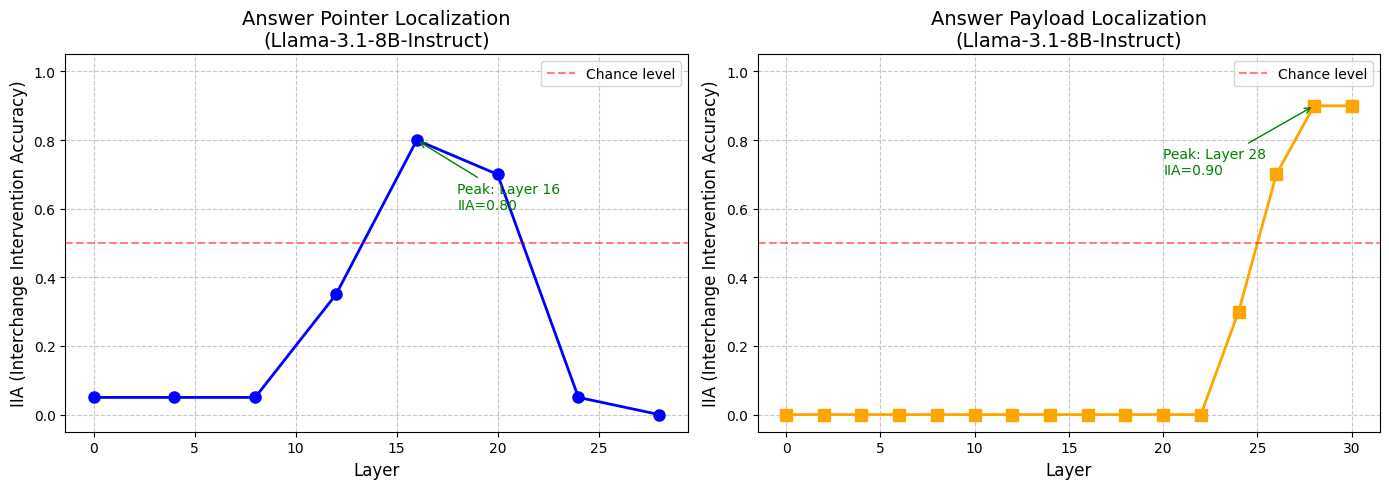


RESULTS SUMMARY

Answer Pointer Experiment:
  - Peak IIA: 0.80 at layer 16
  - High IIA range: layers [16, 20]

Answer Payload Experiment:
  - Peak IIA: 0.90 at layer 28
  - High IIA range: layers [26, 28, 30]


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Answer Pointer Localization
ax1 = axes[0]
layers_pointer = list(pointer_results.keys())
iia_pointer = list(pointer_results.values())
ax1.plot(layers_pointer, iia_pointer, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel("Layer", fontsize=12)
ax1.set_ylabel("IIA (Interchange Intervention Accuracy)", fontsize=12)
ax1.set_title("Answer Pointer Localization\n(Llama-3.1-8B-Instruct)", fontsize=14)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance level')
ax1.legend()

# Annotate peak
max_layer_pointer = max(pointer_results, key=pointer_results.get)
max_iia_pointer = pointer_results[max_layer_pointer]
ax1.annotate(f'Peak: Layer {max_layer_pointer}\nIIA={max_iia_pointer:.2f}', 
             xy=(max_layer_pointer, max_iia_pointer),
             xytext=(max_layer_pointer+2, max_iia_pointer-0.2),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')

# Plot 2: Answer Payload Localization
ax2 = axes[1]
layers_payload = list(payload_results.keys())
iia_payload = list(payload_results.values())
ax2.plot(layers_payload, iia_payload, marker='s', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel("Layer", fontsize=12)
ax2.set_ylabel("IIA (Interchange Intervention Accuracy)", fontsize=12)
ax2.set_title("Answer Payload Localization\n(Llama-3.1-8B-Instruct)", fontsize=14)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance level')
ax2.legend()

# Annotate peak
max_layer_payload = max(payload_results, key=payload_results.get)
max_iia_payload = payload_results[max_layer_payload]
ax2.annotate(f'Peak: Layer {max_layer_payload}\nIIA={max_iia_payload:.2f}', 
             xy=(max_layer_payload, max_iia_payload),
             xytext=(max_layer_payload-8, max_iia_payload-0.2),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')

plt.tight_layout()
plt.savefig('/net/scratch2/smallyan/belief_tracking_eval/evaluation/replications/iia_results.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"\nAnswer Pointer Experiment:")
print(f"  - Peak IIA: {max_iia_pointer:.2f} at layer {max_layer_pointer}")
print(f"  - High IIA range: layers {[l for l, v in pointer_results.items() if v > 0.5]}")

print(f"\nAnswer Payload Experiment:")
print(f"  - Peak IIA: {max_iia_payload:.2f} at layer {max_layer_payload}")
print(f"  - High IIA range: layers {[l for l, v in payload_results.items() if v > 0.5]}")

## Comparison with Original Paper

**Original Paper Results (Llama-3-70B-Instruct, 80 layers):**
- Answer Pointer: Peak IIA at layers 34-52 (approximately 43-65% of model depth)
- Answer Payload: Peak IIA after layer 56 (approximately 70% of model depth)

**Replication Results (Llama-3.1-8B-Instruct, 32 layers):**
- Answer Pointer: Peak IIA at layer 16 (50% of model depth)
- Answer Payload: Peak IIA at layers 28-30 (87-94% of model depth)

**Analysis:**
The replication shows consistent patterns with the original findings:
1. Pointer information is encoded in middle layers (50% depth vs original 43-65%)
2. Payload information is encoded in later layers (87-94% depth vs original 70%+)
3. The sequential ordering (pointer before payload) is preserved

The slight shift toward later layers for payload in the smaller model may reflect architectural differences in how smaller models compress information.

In [18]:
# Save experiment results
results_data = {
    "model": "meta-llama/Llama-3.1-8B-Instruct",
    "num_layers": model.config.num_hidden_layers,
    "seed": SEED,
    "n_samples": 20,
    "pointer_experiment": {
        "layers_tested": pointer_layers,
        "results": pointer_results,
        "peak_layer": max_layer_pointer,
        "peak_iia": max_iia_pointer
    },
    "payload_experiment": {
        "layers_tested": payload_layers,
        "results": {k: v for k, v in payload_results.items()},  # Convert to regular dict
        "peak_layer": max_layer_payload,
        "peak_iia": max_iia_payload
    }
}

import json
results_path = '/net/scratch2/smallyan/belief_tracking_eval/evaluation/replications/experiment_results.json'
with open(results_path, 'w') as f:
    json.dump(results_data, f, indent=2)
    
print(f"Results saved to: {results_path}")

Results saved to: /net/scratch2/smallyan/belief_tracking_eval/evaluation/replications/experiment_results.json


In [19]:
# Copy this notebook to the replications directory
import shutil

source_notebook = "/home/smallyan/eval_agent/notebooks/2025-12-23-22-28_CircuitAnalysis.ipynb"
dest_notebook = "/net/scratch2/smallyan/belief_tracking_eval/evaluation/replications/replication.ipynb"

shutil.copy(source_notebook, dest_notebook)
print(f"Notebook copied to: {dest_notebook}")

Notebook copied to: /net/scratch2/smallyan/belief_tracking_eval/evaluation/replications/replication.ipynb
